# Análise de candidatos do TSE — DuckDB

Carrega os CSVs baixados por `scripts/coleta_tse.py candidatos` (pasta `dados/raw/candidatos/<ano>/`)
direto no DuckDB, sem importar nada para a memória. Resultados de queries viram DataFrame pandas
para plotar.

Formato dos arquivos do TSE: separador `;`, aspas `"`, encoding `cp1252` (latin-1 com alguns bytes extras que aparecem em 2016), decimais com vírgula.

Rodar: `uv run jupyter lab` e abrir este arquivo.

In [ ]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

# raiz do projeto, funcione o notebook sendo aberto de notebooks/ ou da raiz
ROOT = Path.cwd() if (Path.cwd() / "dados").exists() else Path.cwd().parent
RAW = ROOT / "dados" / "raw" / "candidatos"
DB = ROOT / "dados" / "processed" / "tse.duckdb"


# exibe floats como moeda brasileira em vez de notação científica (6.6e+08)
def brl(v):
    return "R$ " + f"{v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


pd.options.display.float_format = brl

con = duckdb.connect(str(DB))
print("banco:", DB)

banco: /home/davi/Documentos/UFPI/6-periodo/BDR/analiseCandidatos/dados/processed/tse.duckdb


## Views sobre os CSVs

`read_csv` com glob lê todos os anos de uma vez. `union_by_name=true` porque o TSE muda colunas entre anos.
`all_varchar=true` evita inferência errada de tipo (CPF, número do candidato com zero à esquerda).
`encoding='cp1252'` precisa da extensão `encodings` (o `latin-1` nativo rejeita bytes 0x81/0x83/0x8A presentes no arquivo de 2016).
Só o arquivo `_BRASIL` de cada ano é lido: ele já contém todos os estados.

In [ ]:
con.execute("INSTALL encodings; LOAD encodings;")  # habilita encoding='cp1252'

CSV_OPTS = "delim=';', quote='\"', header=true, encoding='cp1252', all_varchar=true, union_by_name=true, filename=true"

con.execute(f"""
    CREATE OR REPLACE VIEW candidatos_raw AS
    SELECT * FROM read_csv('{RAW}/*/candidatos_[0-9]*/consulta_cand_[0-9]*_BRASIL.csv', {CSV_OPTS})
""")

con.execute(f"""
    CREATE OR REPLACE VIEW bens_raw AS
    SELECT * FROM read_csv('{RAW}/*/bens_candidato_*/bem_candidato_*_BRASIL.csv', {CSV_OPTS})
""")

con.sql("SELECT ANO_ELEICAO, COUNT(*) AS n FROM candidatos_raw GROUP BY ANO_ELEICAO ORDER BY ANO_ELEICAO").show()

┌─────────────┬────────┐
│ ANO_ELEICAO │   n    │
│   varchar   │ int64  │
├─────────────┼────────┤
│ 2016        │ 498391 │
│ 2018        │  29287 │
│ 2020        │ 558804 │
│ 2022        │  29322 │
│ 2024        │ 463855 │
│ 2026        │  20984 │
└─────────────┴────────┘



In [ ]:
# colunas disponíveis
con.sql("DESCRIBE candidatos_raw").df()[["column_name", "column_type"]]

,column_name,column_type
0,DT_GERACAO,VARCHAR
1,HH_GERACAO,VARCHAR
2,ANO_ELEICAO,VARCHAR
3,CD_TIPO_ELEICAO,VARCHAR
4,NM_TIPO_ELEICAO,VARCHAR
...,...,...
72,SQ_SUBSTITUIDO,VARCHAR
73,SQ_ORDEM_SUPLENCIA,VARCHAR
74,DT_ACEITE_CANDIDATURA,VARCHAR
75,DS_EMAIL,VARCHAR


## Exemplo 1 — candidatos do Piauí por cargo

In [ ]:
con.sql("""
    SELECT ANO_ELEICAO, DS_CARGO, COUNT(*) AS candidatos
    FROM candidatos_raw
    WHERE SG_UF = 'PI'
    GROUP BY 1, 2
    ORDER BY 1, candidatos DESC
""").df()

,ANO_ELEICAO,DS_CARGO,candidatos
0,2016,VEREADOR,9059
1,2016,VICE-PREFEITO,574
2,2016,PREFEITO,569
3,2018,DEPUTADO ESTADUAL,219
4,2018,DEPUTADO FEDERAL,143
5,2018,1º SUPLENTE,20
6,2018,2º SUPLENTE,19
7,2018,SENADOR,18
8,2018,GOVERNADOR,10
9,2018,VICE-GOVERNADOR,10


## Exemplo 2 — patrimônio declarado por candidato (join com bens)

`VR_BEM_CANDIDATO` vem como texto `700000,00`; troca vírgula por ponto e converte.

In [ ]:
patrimonio = con.sql("""
    WITH bens AS (
        SELECT SQ_CANDIDATO,
               SUM(CAST(REPLACE(VR_BEM_CANDIDATO, ',', '.') AS DECIMAL(18,2))) AS total_bens
        FROM bens_raw
        GROUP BY 1
    )
    SELECT c.ANO_ELEICAO, c.NM_URNA_CANDIDATO, c.SG_PARTIDO, c.DS_CARGO, b.total_bens
    FROM candidatos_raw c
    JOIN bens b USING (SQ_CANDIDATO)
    WHERE c.SG_UF = 'PI'
    ORDER BY b.total_bens DESC
    LIMIT 20
""").df()
patrimonio

,ANO_ELEICAO,NM_URNA_CANDIDATO,SG_PARTIDO,DS_CARGO,total_bens
0,2024,DR VINICIUS,PSD,VEREADOR,"R$ 660.000.000,00"
1,2024,FATIMA CARMINO,PT,VEREADOR,"R$ 415.293.804,00"
2,2022,TELMO NEVES,PP,DEPUTADO ESTADUAL,"R$ 128.678.000,00"
3,2022,JADYEL DA JUPI,PV,DEPUTADO FEDERAL,"R$ 107.545.780,55"
4,2026,JADYEL,REPUBLICANOS,DEPUTADO FEDERAL,"R$ 107.108.276,43"
5,2020,ARAUJINHO,PT,PREFEITO,"R$ 53.712.239,05"
6,2016,PAULO LIMEIRA,PR,PREFEITO,"R$ 38.033.000,00"
7,2026,CIRO NOGUEIRA,PP,SENADOR,"R$ 34.610.258,62"
8,2026,PAULO LIMEIRA,AVANTE,1º SUPLENTE,"R$ 31.140.000,00"
9,2018,CIRO NOGUEIRA,PP,SENADOR,"R$ 23.314.081,45"


## Exemplo 3 — resultado em pandas + gráfico

DS_GENERO,FEMININO,MASCULINO,NÃO DIVULGÁVEL
ANO_ELEICAO,,,
2016,"R$ 3.252,00","R$ 6.950,00","R$ 0,00"
2018,"R$ 137,00","R$ 302,00","R$ 0,00"
2020,"R$ 3.555,00","R$ 7.141,00","R$ 10,00"
2022,"R$ 154,00","R$ 279,00","R$ 0,00"
2024,"R$ 3.012,00","R$ 5.966,00","R$ 0,00"
2026,"R$ 138,00","R$ 264,00","R$ 0,00"


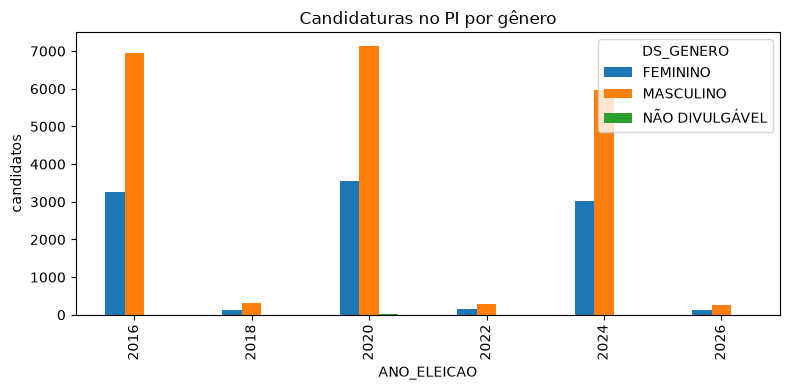

In [ ]:
genero = con.sql("""
    SELECT ANO_ELEICAO, DS_GENERO, COUNT(*) AS n
    FROM candidatos_raw
    WHERE SG_UF = 'PI'
    GROUP BY 1, 2
""").df()

tabela = genero.pivot(index="ANO_ELEICAO", columns="DS_GENERO", values="n").fillna(0)
tabela.plot(kind="bar", figsize=(8, 4), title="Candidaturas no PI por gênero")
plt.ylabel("candidatos")
plt.tight_layout()
tabela

## Próximos passos

- Modelar o DER (candidato, eleição, partido, cargo, unidade eleitoral, bem, coligação).
- Escrever `sql/schema.sql` com `CREATE TABLE` + PK/FK e carregar as tabelas normalizadas a partir
  das views `*_raw` (`INSERT INTO ... SELECT DISTINCT ...`).
- Responder as perguntas do trabalho com queries sobre o esquema normalizado.

O arquivo `dados/processed/tse.duckdb` guarda as views e tabelas criadas aqui.

In [ ]:
con.close()